# $$\Huge{\text{Análisis de Estudiantes ITLA 📊}}$$

$$\Large{\text{Estadísticas de Estudiantes Inscritos, 2006 - 2025}}$$

#*BY:*

1. Lyan Angomas
2. Eimy Karolina
3. Lisandro Mercedes
5. Robert Yarel

#Importaciones

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

#Carga de datos

In [ ]:
df = pd.read_csv ("Estadisticas-Inscritos-Educacion-Superior-2006-2025.csv")
df

,Carrera,Estudiantes femeninos,Estudiantes masculinos,Cuatrimestre,Año
0,Tecnólogo en Desarrollo de Software,3,6,Septiembre- Diciembre,2006
1,Tecnólogo en Multimedia,8,9,Septiembre- Diciembre,2006
2,Tecnólogo en Redes de Información,13,19,Septiembre- Diciembre,2006
3,Tecnólogo en Manufactura Automatizada,8,5,Septiembre- Diciembre,2006
4,Tecnólogo en Desarrollo de Software,8,13,Enero - Abril,2007
...,...,...,...,...,...
470,Tecnólogo en Multimedia,500,476,Septiembre- Diciembre,2025
471,Tecnólogo en Redes de la Información,32,202,Septiembre- Diciembre,2025
472,Tecnólogo en Seguridad Informática,194,1173,Septiembre- Diciembre,2025
473,Tecnólogo en Sonido,11,94,Septiembre- Diciembre,2025


#Preparacion de datos

##Selección de los últimos 10 años

In [ ]:
df = df[df["Año"] >= 2016].copy()
df

,Carrera,Estudiantes femeninos,Estudiantes masculinos,Cuatrimestre,Año
137,Tecnólogo en Desarrollo de Software,62,392,Enero - Abril,2016
138,Tecnólogo en Manufactura Automatizada,13,21,Enero - Abril,2016
139,Tecnólogo en Mecatrónica,19,187,Enero - Abril,2016
140,Tecnólogo en Multimedia,106,183,Enero - Abril,2016
141,Tecnólogo en Redes de Información,53,230,Enero - Abril,2016
...,...,...,...,...,...
470,Tecnólogo en Multimedia,500,476,Septiembre- Diciembre,2025
471,Tecnólogo en Redes de la Información,32,202,Septiembre- Diciembre,2025
472,Tecnólogo en Seguridad Informática,194,1173,Septiembre- Diciembre,2025
473,Tecnólogo en Sonido,11,94,Septiembre- Diciembre,2025


##Detalles del dataset

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 338 entries, 137 to 474
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Carrera                 338 non-null    object
 1   Estudiantes femeninos   338 non-null    int64 
 2   Estudiantes masculinos  338 non-null    int64 
 3   Cuatrimestre            338 non-null    object
 4   Año                     338 non-null    int64 
dtypes: int64(3), object(2)
memory usage: 15.8+ KB


##Verificacion nulls

In [ ]:
print("Cantidad de registros con datos nulos:", df.isna().any(axis=1).sum())

Cantidad de registros con datos nulos: 0


##Verificacion duplicados

In [ ]:
print("Cantidad de registros duplicados:", df.duplicated().sum())

Cantidad de registros duplicados: 0


#Ingenieria de Caracteristicas

##Columna total de estudiantes M y F por Carrera

In [ ]:
df["Total"] = df["Estudiantes femeninos"] + df["Estudiantes masculinos"]

##Numero Cuatrimestre

In [ ]:
df['Numero de Cuatrimestre'] = df['Cuatrimestre'].map({
    'Enero - Abril': 1,
    'Mayo - Agosto': 2,
    'Septiembre- Diciembre': 3
})

##Nivel demanda carrera

In [ ]:
df['Nivel de demanda'] = pd.cut(df['Total'], bins=[-1, 50, 150, df["Total"].max() + 1],
                              labels=['Baja', 'Media', 'Alta'])

In [ ]:
df

,Carrera,Estudiantes femeninos,Estudiantes masculinos,Cuatrimestre,Año,Total,Numero de Cuatrimestre,Nivel de demanda
137,Tecnólogo en Desarrollo de Software,62,392,Enero - Abril,2016,454,1,Alta
138,Tecnólogo en Manufactura Automatizada,13,21,Enero - Abril,2016,34,1,Baja
139,Tecnólogo en Mecatrónica,19,187,Enero - Abril,2016,206,1,Alta
140,Tecnólogo en Multimedia,106,183,Enero - Abril,2016,289,1,Alta
141,Tecnólogo en Redes de Información,53,230,Enero - Abril,2016,283,1,Alta
...,...,...,...,...,...,...,...,...
470,Tecnólogo en Multimedia,500,476,Septiembre- Diciembre,2025,976,3,Alta
471,Tecnólogo en Redes de la Información,32,202,Septiembre- Diciembre,2025,234,3,Alta
472,Tecnólogo en Seguridad Informática,194,1173,Septiembre- Diciembre,2025,1367,3,Alta
473,Tecnólogo en Sonido,11,94,Septiembre- Diciembre,2025,105,3,Media


#Analisis Exploratorio de la Data

In [ ]:
df.describe()

,Estudiantes femeninos,Estudiantes masculinos,Año,Total,Numero de Cuatrimestre
count,338.000000,338.000000,338.000000,338.000000,338.000000
mean,68.357988,264.201183,2021.446746,332.559172,2.014793
std,104.519470,398.351344,2.660594,470.220446,0.816968
min,0.000000,2.000000,2016.000000,4.000000,1.000000
25%,8.000000,41.000000,2020.000000,52.250000,1.000000
50%,28.000000,99.500000,2022.000000,137.000000,2.000000
75%,69.250000,305.000000,2024.000000,362.750000,3.000000
max,712.000000,2038.000000,2025.000000,2395.000000,3.000000


##Tecnologos/ Carreras del ITLA

In [ ]:
for carrera in sorted(df["Carrera"].unique()):
    print(carrera)

Tecnólogo en Analítica y Ciencia de los Datos
Tecnólogo en Ciberseguridad
Tecnólogo en Desarrollo de Simulaciones Interactivas y Videojuegos
Tecnólogo en Desarrollo de Software
Tecnólogo en Diseño Industrial
Tecnólogo en Dispositivos Médicos
Tecnólogo en Energías Renovables
Tecnólogo en Informática Forense
Tecnólogo en Inteligencia Artificial
Tecnólogo en Manufactura Automatizada
Tecnólogo en Manufactura de Dispositivos Médicos 
Tecnólogo en Mecatrónica
Tecnólogo en Multimedia
Tecnólogo en Multimedia 
Tecnólogo en Redes de Información
Tecnólogo en Redes de la Información
Tecnólogo en Seguridad Informática
Tecnólogo en Seguridad Informática 
Tecnólogo en Sonido
Tecnólogo en Telecomunicaciones


###Solucion carreras repetidas

In [ ]:
df["Carrera"] = df["Carrera"].str.strip()

In [ ]:
df["Carrera"] = df["Carrera"].replace({
    "Tecnólogo en Redes de la Información": "Tecnólogo en Redes de Información"
})

In [ ]:
for carrera in sorted(df["Carrera"].unique()):
    print(carrera)

Tecnólogo en Analítica y Ciencia de los Datos
Tecnólogo en Ciberseguridad
Tecnólogo en Desarrollo de Simulaciones Interactivas y Videojuegos
Tecnólogo en Desarrollo de Software
Tecnólogo en Diseño Industrial
Tecnólogo en Dispositivos Médicos
Tecnólogo en Energías Renovables
Tecnólogo en Informática Forense
Tecnólogo en Inteligencia Artificial
Tecnólogo en Manufactura Automatizada
Tecnólogo en Manufactura de Dispositivos Médicos
Tecnólogo en Mecatrónica
Tecnólogo en Multimedia
Tecnólogo en Redes de Información
Tecnólogo en Seguridad Informática
Tecnólogo en Sonido
Tecnólogo en Telecomunicaciones


##Carreras con mas estudiantes

In [ ]:
carreras = df.groupby("Carrera").agg({
    "Estudiantes masculinos":"sum",
    "Estudiantes femeninos":"sum",
    "Total":"sum"
}).sort_values("Total", ascending=False)

carreras

,Estudiantes masculinos,Estudiantes femeninos,Total
Carrera,,,
Tecnólogo en Desarrollo de Software,36121,6217,42338
Tecnólogo en Multimedia,10193,7891,18084
Tecnólogo en Seguridad Informática,12597,2267,14864
Tecnólogo en Mecatrónica,8664,1264,9928
Tecnólogo en Redes de Información,6651,1351,8002
Tecnólogo en Sonido,5320,861,6181
Tecnólogo en Analítica y Ciencia de los Datos,1751,763,2514
Tecnólogo en Manufactura Automatizada,1810,348,2158
Tecnólogo en Desarrollo de Simulaciones Interactivas y Videojuegos,1506,240,1746


In [ ]:
#Numero total de estudiantes
df["Total"].sum()

np.int64(112405)

# 10 carreras con mas estudiantes

In [ ]:
top10 = carreras.nlargest(10, "Total")
top10

,Estudiantes masculinos,Estudiantes femeninos,Total
Carrera,,,
Tecnólogo en Desarrollo de Software,36121,6217,42338
Tecnólogo en Multimedia,10193,7891,18084
Tecnólogo en Seguridad Informática,12597,2267,14864
Tecnólogo en Mecatrónica,8664,1264,9928
Tecnólogo en Redes de Información,6651,1351,8002
Tecnólogo en Sonido,5320,861,6181
Tecnólogo en Analítica y Ciencia de los Datos,1751,763,2514
Tecnólogo en Manufactura Automatizada,1810,348,2158
Tecnólogo en Desarrollo de Simulaciones Interactivas y Videojuegos,1506,240,1746


10 carreras con menos

In [ ]:
menos10 = carreras.nsmallest(10, "Total")
menos10

,Estudiantes masculinos,Estudiantes femeninos,Total
Carrera,,,
Tecnólogo en Ciberseguridad,152,22,174
Tecnólogo en Dispositivos Médicos,125,83,208
Tecnólogo en Manufactura de Dispositivos Médicos,353,217,570
Tecnólogo en Telecomunicaciones,574,68,642
Tecnólogo en Energías Renovables,549,95,644
Tecnólogo en Inteligencia Artificial,1051,334,1385
Tecnólogo en Informática Forense,1043,415,1458
Tecnólogo en Diseño Industrial,840,669,1509
Tecnólogo en Desarrollo de Simulaciones Interactivas y Videojuegos,1506,240,1746


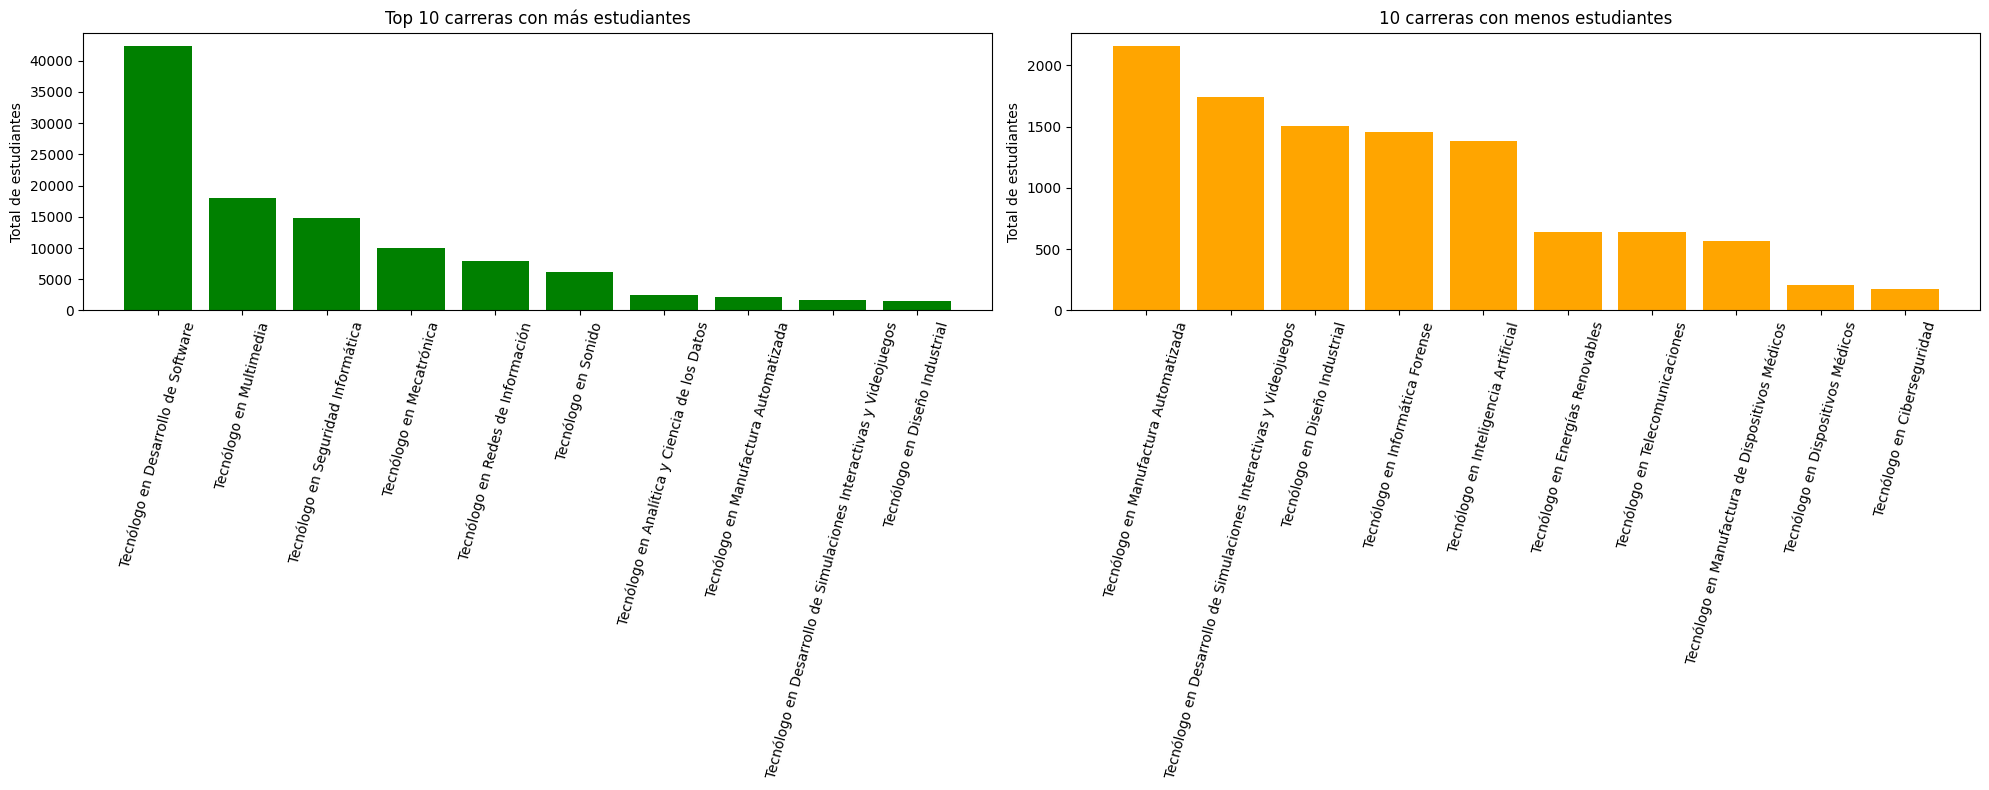

In [ ]:
top10 = carreras.sort_values("Total", ascending=False).head(10)
menos10 = carreras.sort_values("Total").head(10).sort_values("Total", ascending=False)

fig, ax = plt.subplots(1, 2, figsize=(20,8))

# Top 10 carreras
ax[0].bar(top10.index, top10["Total"], color="green")
ax[0].set_title("Top 10 carreras con más estudiantes")
ax[0].set_ylabel("Total de estudiantes")
ax[0].tick_params(axis="x", rotation=75)

# 10 carreras con menos estudiantes
ax[1].bar(menos10.index, menos10["Total"], color="orange")
ax[1].set_title("10 carreras con menos estudiantes")
ax[1].set_ylabel("Total de estudiantes")
ax[1].tick_params(axis="x", rotation=75)

plt.tight_layout()
plt.show()

##Crecimiento del ITLA en cuanto a estudiantes de 2016 a 2025

In [ ]:
t2016 = df[df["Año"] == 2016]["Total"].sum()
t2025 = df[df["Año"] == 2025]["Total"].sum()

print(f"Cantidad de estudiantes en el año 2016: {t2016}")
print(f"Cantidad de estudiantes en el año 2025: {t2025}")
print(f"Crecimiento: {t2025 - t2016} estudiantes más.")

Cantidad de estudiantes en el año 2016: 3669
Cantidad de estudiantes en el año 2025: 20296
Crecimiento: 16627 estudiantes más.


In [ ]:
aumento = t2025 - t2016
crecimiento = aumento / t2016 * 100

print(f"Aumento de estudiantes: {aumento}")
print(f"Crecimiento porcentual: {crecimiento:.1f}%")

Aumento de estudiantes: 16627
Crecimiento porcentual: 453.2%


##Carreras con mayor crecimiento porcentual (cambio t)

In [ ]:
comienzo = df[df["Año"] == 2016].groupby("Carrera")["Total"].sum()
termino = df[df["Año"] == 2025].groupby("Carrera")["Total"].sum()

tabla = pd.DataFrame({
    "2016": comienzo,
    "2025": termino
})

tabla["Crecimiento %"] = ((tabla["2025"] - tabla["2016"]) / tabla["2016"] * 100).round(1)

tabla = tabla.dropna().sort_values("Crecimiento %", ascending=False)
tabla

,2016,2025,Crecimiento %
Carrera,,,
Tecnólogo en Seguridad Informática,46.0,4108,8830.4
Tecnólogo en Sonido,25.0,320,1180.0
Tecnólogo en Desarrollo de Software,1333.0,7020,426.6
Tecnólogo en Multimedia,791.0,2944,272.2
Tecnólogo en Mecatrónica,591.0,1151,94.8
Tecnólogo en Manufactura Automatizada,88.0,138,56.8
Tecnólogo en Redes de Información,795.0,758,-4.7


###Verificacion de inscripciones de Tecnologo en RI por año

In [ ]:
print("2016:", df[(df["Carrera"] == "Tecnólogo en Redes de Información") & (df["Año"] == 2016)]["Total"].sum())
print("2025:", df[(df["Carrera"] == "Tecnólogo en Redes de Información") & (df["Año"] == 2025)]["Total"].sum())

2016: 795
2025: 758


In [ ]:
df[df["Carrera"] == "Tecnólogo en Redes de Información"].groupby("Año")["Total"].sum()

,Total
Año,
2016,795
2017,932
2018,859
2019,963
2020,822
2021,869
2022,700
2023,616
2024,688


##Carreras en -crecimiento

In [ ]:
print(tabla[tabla["Crecimiento %"] < 0])

                                    2016  2025  Crecimiento %
Carrera                                                      
Tecnólogo en Redes de Información  795.0   758           -4.7


##Estudiantes inscritos segun el año

In [ ]:
inscritos_año = df.groupby("Año").agg({
    "Estudiantes masculinos":"sum",
    "Estudiantes femeninos":"sum",
    "Total":"sum"
}).reset_index()

inscritos_año

,Año,Estudiantes masculinos,Estudiantes femeninos,Total
0,2016,2967,702,3669
1,2017,2847,2197,5044
2,2018,5280,1048,6328
3,2019,6902,1449,8351
4,2020,7754,1660,9414
5,2021,10269,2246,12515
6,2022,11362,2625,13987
7,2023,11888,2897,14785
8,2024,14237,3779,18016
9,2025,15794,4502,20296


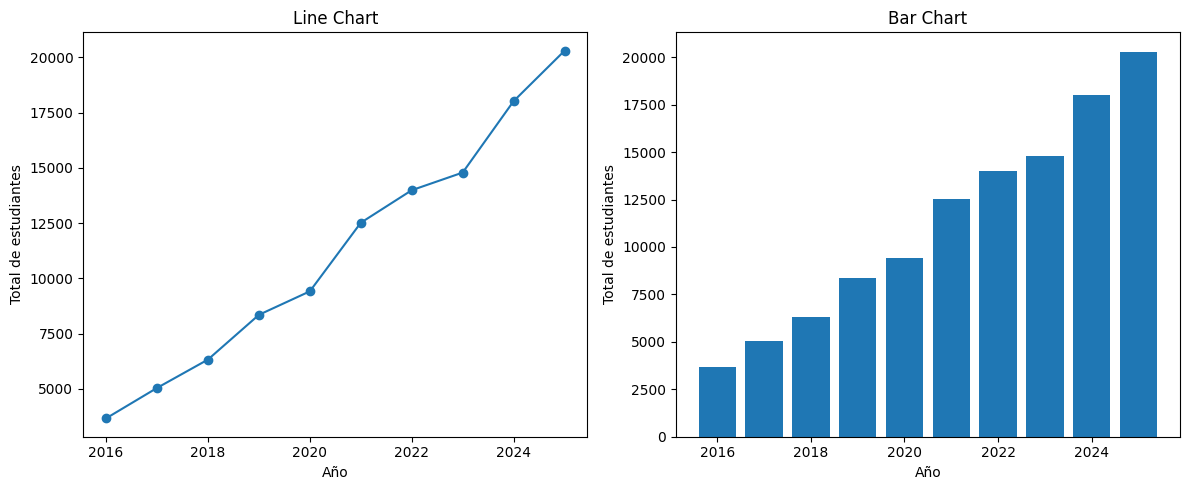

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12,5))

# Line chart
ax[0].plot(inscritos_año["Año"],
           inscritos_año["Total"],
           marker="o")

ax[0].set_title("Line Chart")
ax[0].set_ylabel("Total de estudiantes")
ax[0].set_xlabel("Año")

# Bar chart
ax[1].bar(inscritos_año["Año"],
          inscritos_año["Total"])

ax[1].set_title("Bar Chart")
ax[1].set_ylabel("Total de estudiantes")
ax[1].set_xlabel("Año")

plt.tight_layout()
plt.show()

##Distribucion por Sexo

In [ ]:
distribucion = df[["Estudiantes masculinos", "Estudiantes femeninos"]].agg("sum")
print(distribucion)

Estudiantes masculinos    89300
Estudiantes femeninos     23105
dtype: int64


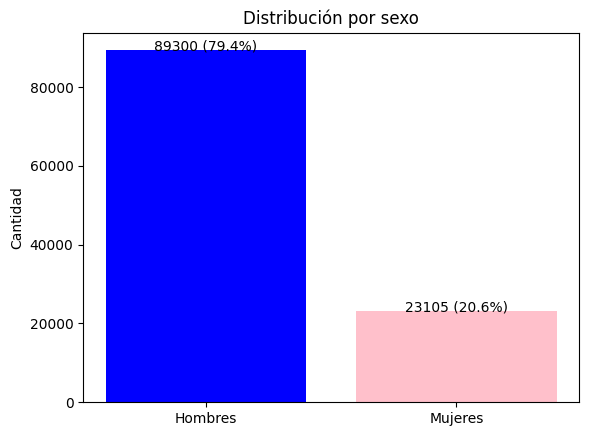

In [ ]:
masculinos = df["Estudiantes masculinos"].sum()
femeninos = df["Estudiantes femeninos"].sum()

labels = ["Hombres","Mujeres"]
values = [masculinos, femeninos]

total = sum(values)

plt.bar(labels, values, color=["blue","pink"])

for i, v in enumerate(values):
    porcentaje = (v / total) * 100
    plt.text(i, v + 10, f"{v} ({porcentaje:.1f}%)", ha="center")

plt.title("Distribución por sexo")
plt.ylabel("Cantidad")

plt.show()

###Como ha eveolucionado el sexo femenino

In [ ]:
inscritos_año["% Mujeres"] = (
    inscritos_año["Estudiantes femeninos"] /
    inscritos_año["Total"]
) * 100

inscritos_año["% Mujeres"] = inscritos_año["% Mujeres"].round(2)

inscritos_año

,Año,Estudiantes masculinos,Estudiantes femeninos,Total,% Mujeres
0,2016,2967,702,3669,19.13
1,2017,2847,2197,5044,43.56
2,2018,5280,1048,6328,16.56
3,2019,6902,1449,8351,17.35
4,2020,7754,1660,9414,17.63
5,2021,10269,2246,12515,17.95
6,2022,11362,2625,13987,18.77
7,2023,11888,2897,14785,19.59
8,2024,14237,3779,18016,20.98
9,2025,15794,4502,20296,22.18


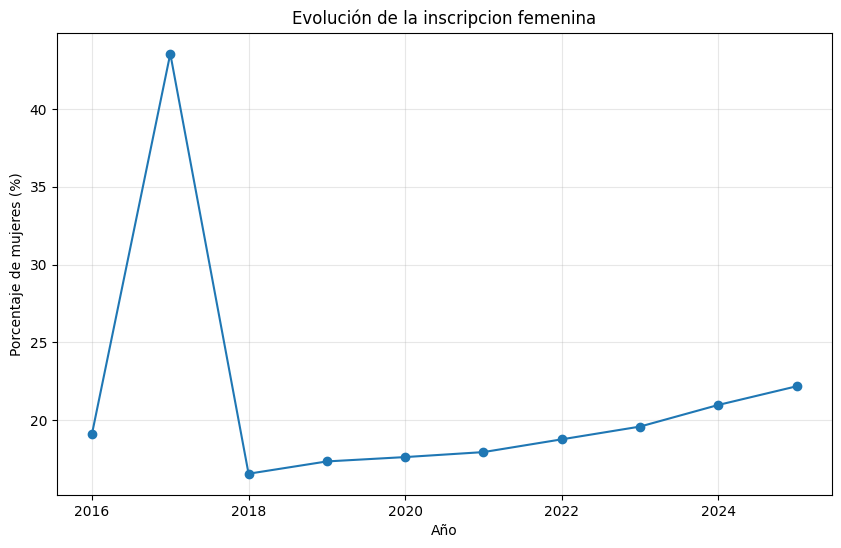

In [ ]:
plt.figure(figsize=(10,6))

plt.plot(inscritos_año["Año"],
         inscritos_año["% Mujeres"],
         marker="o")

plt.title("Evolución de la inscripcion femenina")
plt.xlabel("Año")
plt.ylabel("Porcentaje de mujeres (%)")

plt.grid(alpha=0.3)

plt.show()

ANOMALIA

In [ ]:
print(inscritos_año[inscritos_año["Año"] == 2017])

    Año  Estudiantes masculinos  Estudiantes femeninos  Total  % Mujeres
1  2017                    2847                   2197   5044      43.56


In [ ]:
df[df["Año"] == 2017].groupby("Carrera")[["Estudiantes femeninos"]].sum().sort_values("Estudiantes femeninos", ascending=False).head(5)

,Estudiantes femeninos
Carrera,
Tecnólogo en Desarrollo de Software,857
Tecnólogo en Multimedia,416
Tecnólogo en Redes de Información,398
Tecnólogo en Mecatrónica,295
Tecnólogo en Seguridad Informática,143


In [ ]:
df[df["Carrera"] == "Tecnólogo en Desarrollo de Software"].groupby("Año")["Estudiantes femeninos"].sum()

,Estudiantes femeninos
Año,
2016,174
2017,857
2018,218
2019,449
2020,469
2021,576
2022,722
2023,766
2024,929


In [ ]:
temp_df = df[(df["Carrera"] == "Tecnólogo en Desarrollo de Software") &
   (df["Año"] == 2017)].copy()
temp_df["Total"] = temp_df["Estudiantes femeninos"] + temp_df["Estudiantes masculinos"]
temp_df[["Cuatrimestre", "Estudiantes femeninos", "Estudiantes masculinos", "Total"]]

,Cuatrimestre,Estudiantes femeninos,Estudiantes masculinos,Total
154,Enero - Abril,78,538,616
162,Mayo - Agosto,67,501,568
170,Septiembre- Diciembre,712,100,812


In [ ]:
df[(df["Carrera"] == "Tecnólogo en Desarrollo de Software") &
   (df["Cuatrimestre"] == "Septiembre- Diciembre")][["Año", "Estudiantes femeninos", "Estudiantes masculinos", "Total"]]

,Año,Estudiantes femeninos,Estudiantes masculinos,Total
147,2016,64,446,510
170,2017,712,100,812
191,2018,6,49,55
213,2019,162,1065,1227
241,2020,146,1090,1236
283,2021,205,1387,1592
325,2022,247,1628,1875
370,2023,273,1853,2126
415,2024,305,1955,2260
462,2025,355,1931,2286


In [ ]:
inicio = inscritos_año.iloc[0]["% Mujeres"]
final = inscritos_año.iloc[-1]["% Mujeres"]

cambio = final - inicio

print("Inscripcion femenina en 2016:", inicio, "%")
print("Inscripcion femenina en 2025:", final, "%")
print("Cambio:", round(cambio,2), "%")

Inscripcion femenina en 2016: 19.13 %
Inscripcion femenina en 2025: 22.18 %
Cambio: 3.05 %


###Tecnologos con mas femeninas

In [ ]:
df.groupby("Carrera")["Estudiantes femeninos"].sum().sort_values(ascending=False)

,Estudiantes femeninos
Carrera,
Tecnólogo en Multimedia,7891
Tecnólogo en Desarrollo de Software,6217
Tecnólogo en Seguridad Informática,2267
Tecnólogo en Redes de Información,1351
Tecnólogo en Mecatrónica,1264
Tecnólogo en Sonido,861
Tecnólogo en Analítica y Ciencia de los Datos,763
Tecnólogo en Diseño Industrial,669
Tecnólogo en Informática Forense,415


##periodo con la mayor cantidad de estudiantes

In [ ]:
periodo = df.groupby("Cuatrimestre")["Total"].sum().sort_values(ascending=False)
print(periodo)

Cuatrimestre
Septiembre- Diciembre    38873
Enero - Abril            37549
Mayo - Agosto            35983
Name: Total, dtype: int64


## Periodo con mas inscripciones por año

In [ ]:
cuatri_año = df.groupby(["Año", "Cuatrimestre"])["Total"].sum().reset_index()
ganadores = cuatri_año.loc[cuatri_año.groupby("Año")["Total"].idxmax()]
ganadores = ganadores.reset_index(drop=True)
ganadores

,Año,Cuatrimestre,Total
0,2016,Septiembre- Diciembre,1408
1,2017,Septiembre- Diciembre,2002
2,2018,Septiembre- Diciembre,2360
3,2019,Septiembre- Diciembre,3066
4,2020,Enero - Abril,3306
5,2021,Enero - Abril,4367
6,2022,Septiembre- Diciembre,4754
7,2023,Septiembre- Diciembre,5178
8,2024,Septiembre- Diciembre,6059
9,2025,Enero - Abril,6827


nivel demnda

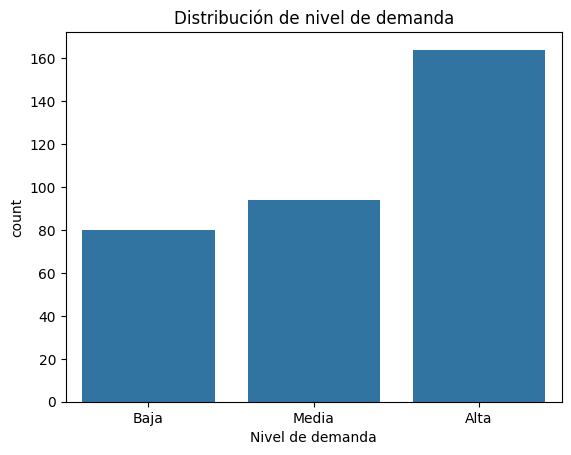

In [ ]:
sns.countplot(data=df, x="Nivel de demanda", order=["Baja", "Media", "Alta"])
plt.title("Distribución de nivel de demanda")
plt.show()

##Efecto Pandemia

In [ ]:
df

,Carrera,Estudiantes femeninos,Estudiantes masculinos,Cuatrimestre,Año,Total,Numero de Cuatrimestre,Nivel de demanda
137,Tecnólogo en Desarrollo de Software,62,392,Enero - Abril,2016,454,1,Alta
138,Tecnólogo en Manufactura Automatizada,13,21,Enero - Abril,2016,34,1,Baja
139,Tecnólogo en Mecatrónica,19,187,Enero - Abril,2016,206,1,Alta
140,Tecnólogo en Multimedia,106,183,Enero - Abril,2016,289,1,Alta
141,Tecnólogo en Redes de Información,53,230,Enero - Abril,2016,283,1,Alta
...,...,...,...,...,...,...,...,...
470,Tecnólogo en Multimedia,500,476,Septiembre- Diciembre,2025,976,3,Alta
471,Tecnólogo en Redes de Información,32,202,Septiembre- Diciembre,2025,234,3,Alta
472,Tecnólogo en Seguridad Informática,194,1173,Septiembre- Diciembre,2025,1367,3,Alta
473,Tecnólogo en Sonido,11,94,Septiembre- Diciembre,2025,105,3,Media


In [ ]:
inscritos_año["Periodo"] = "Antes"
inscritos_año.loc[inscritos_año["Año"].isin([2020,2021]), "Periodo"] = "Pandemia"
inscritos_año.loc[inscritos_año["Año"] > 2021, "Periodo"] = "Después"

In [ ]:
inscritos_año

,Año,Estudiantes masculinos,Estudiantes femeninos,Total,% Mujeres,Periodo
0,2016,2967,702,3669,19.13,Antes
1,2017,2847,2197,5044,43.56,Antes
2,2018,5280,1048,6328,16.56,Antes
3,2019,6902,1449,8351,17.35,Antes
4,2020,7754,1660,9414,17.63,Pandemia
5,2021,10269,2246,12515,17.95,Pandemia
6,2022,11362,2625,13987,18.77,Después
7,2023,11888,2897,14785,19.59,Después
8,2024,14237,3779,18016,20.98,Después
9,2025,15794,4502,20296,22.18,Después


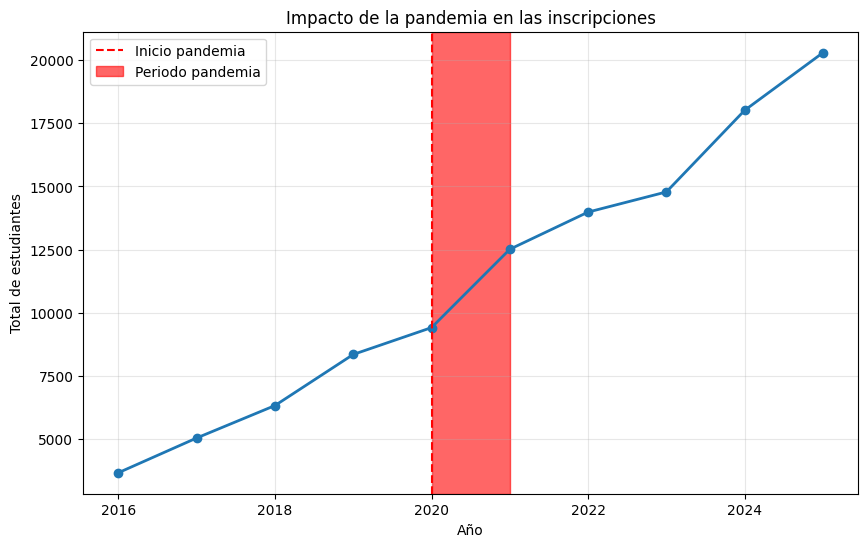

In [ ]:
plt.figure(figsize=(10,6))

plt.plot(inscritos_año["Año"],
         inscritos_año["Total"],
         marker="o",
         linewidth=2)

# línea inicio pandemia
plt.axvline(x=2020, color="red", linestyle="--", label="Inicio pandemia")


plt.axvspan(2020, 2021, color="red", alpha=0.6, label="Periodo pandemia")

plt.title("Impacto de la pandemia en las inscripciones")
plt.xlabel("Año")
plt.ylabel("Total de estudiantes")

plt.grid(alpha=0.3)
plt.legend()

plt.show()

In [ ]:
antes = inscritos_año[inscritos_año["Año"] < 2020]["Total"].mean()

pandemia = inscritos_año[(inscritos_año["Año"] >= 2020) & (inscritos_año["Año"] <= 2021)]["Total"].mean()

despues = inscritos_año[inscritos_año["Año"] > 2021]["Total"].mean()

print("Promedio antes pandemia:", round(antes))
print("Promedio durante pandemia:", round(pandemia))
print("Promedio después pandemia:", round(despues))

Promedio antes pandemia: 5848
Promedio durante pandemia: 10964
Promedio después pandemia: 16771


In [ ]:
antes = inscritos_año[inscritos_año["Año"] < 2020]["Total"].mean()
pandemia_mean = inscritos_año[(inscritos_año["Año"] >= 2020) & (inscritos_año["Año"] <= 2021)]["Total"].mean()
despues = inscritos_año[inscritos_año["Año"] > 2021]["Total"].mean()

crecimiento_pandemia = ((pandemia_mean - antes) / antes) * 100
crecimiento_despues = ((despues - pandemia_mean) / pandemia_mean) * 100
crecimiento_total = ((despues - antes) / antes) * 100

print("Cambio antes → pandemia:", round(crecimiento_pandemia,1), "%")
print("Cambio pandemia → después:", round(crecimiento_despues,1), "%")
print("Cambio antes → después:", round(crecimiento_total,1), "%")

Cambio antes → pandemia: 87.5 %
Cambio pandemia → después: 53.0 %
Cambio antes → después: 186.8 %


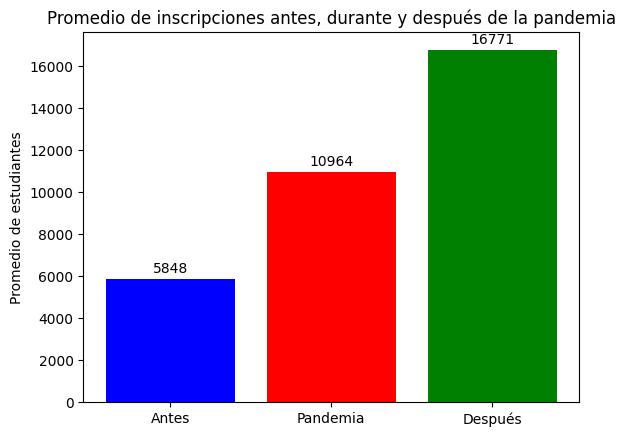

In [ ]:
periodos = ["Antes", "Pandemia", "Después"]
valores = [antes, pandemia_mean, despues]

plt.bar(periodos, valores, color=["blue","red","green"])

for i,v in enumerate(valores):
    plt.text(i, v+300, str(round(v)), ha="center")

plt.title("Promedio de inscripciones antes, durante y después de la pandemia")
plt.ylabel("Promedio de estudiantes")

plt.show()

In [ ]:
pandemia = df[df["Año"].isin([2020, 2021])]

crecimiento_pandemia = pandemia.groupby("Carrera")["Total"].sum().sort_values(ascending=False)

print(crecimiento_pandemia.head(10))

Carrera
Tecnólogo en Desarrollo de Software              8491
Tecnólogo en Multimedia                          3666
Tecnólogo en Sonido                              2905
Tecnólogo en Mecatrónica                         2420
Tecnólogo en Redes de Información                1691
Tecnólogo en Seguridad Informática               1435
Tecnólogo en Diseño Industrial                    272
Tecnólogo en Manufactura Automatizada             272
Tecnólogo en Analítica y Ciencia de los Datos     261
Tecnólogo en Dispositivos Médicos                 142
Name: Total, dtype: int64


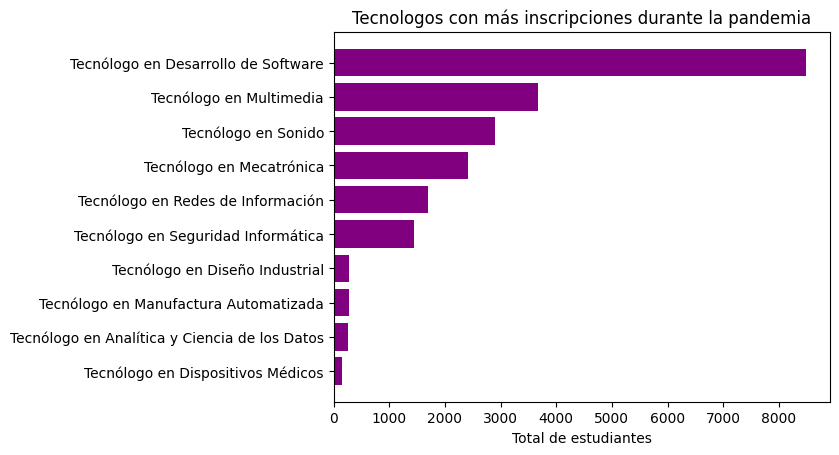

In [ ]:
top_pandemia = crecimiento_pandemia.head(10)

plt.barh(top_pandemia.index, top_pandemia.values, color="purple")

plt.title("Tecnologos con más inscripciones durante la pandemia")
plt.xlabel("Total de estudiantes")

plt.gca().invert_yaxis()

plt.show()

##Tecnologos emergentes vs tradicionales

In [ ]:
tradicionales = [
"Tecnólogo en Desarrollo de Software",
"Tecnólogo en Redes de Información",
"Tecnólogo en Multimedia"
]

emergentes = [
"Tecnólogo en Inteligencia Artificial",
"Tecnólogo en Seguridad Informática",
"Tecnólogo en Analítica y Ciencia de los Datos",
"Tecnólogo en Desarrollo de Simulaciones Interactivas y Videojuegos"
]

In [ ]:
tradicional = df[df["Carrera"].isin(tradicionales)]
emergente = df[df["Carrera"].isin(emergentes)]

In [ ]:
tradicional_año = tradicional.groupby("Año")["Total"].sum().reset_index()
emergente_año = emergente.groupby("Año")["Total"].sum().reset_index()

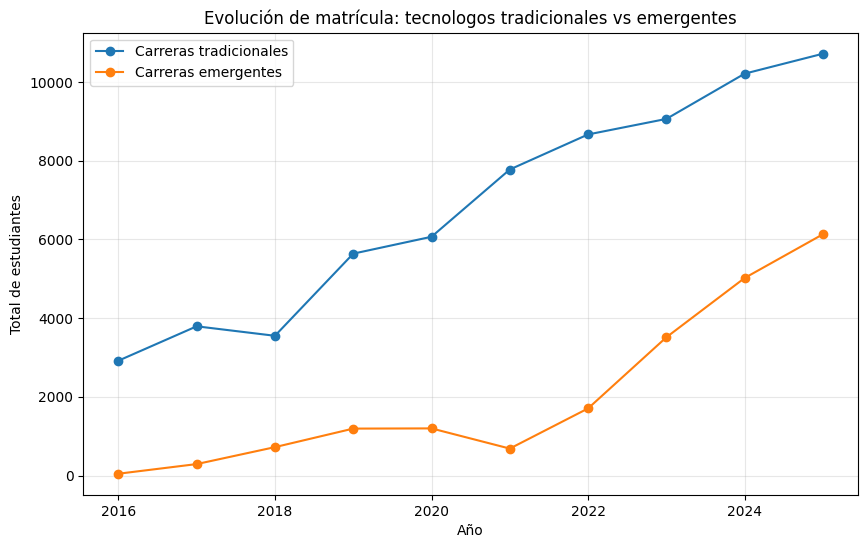

In [ ]:
plt.figure(figsize=(10,6))

plt.plot(tradicional_año["Año"],
         tradicional_año["Total"],
         marker="o",
         label="Carreras tradicionales")

plt.plot(emergente_año["Año"],
         emergente_año["Total"],
         marker="o",
         label="Carreras emergentes")

plt.title("Evolución de matrícula: tecnologos tradicionales vs emergentes")
plt.xlabel("Año")
plt.ylabel("Total de estudiantes")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [ ]:
rd = ("-_-")
rd

'-_-'

#Analisis predictivo

##inscripciones para 2026

Evaluación con Train/Test
Entrenado con 2016-2023, evaluado con 2024-2025

In [ ]:
matricula_anual = df.groupby("Año")["Total"].sum().reset_index()

train = matricula_anual[matricula_anual["Año"] <= 2023]
test  = matricula_anual[matricula_anual["Año"] > 2023]

X_train = train[["Año"]]
y_train = train["Total"]

X_test = test[["Año"]]
y_test = test["Total"]

modelo = LinearRegression()
modelo.fit(X_train, y_train)

print("R² test:", round(r2_score(y_test, modelo.predict(X_test)),4))
print("MAE test:", round(mean_absolute_error(y_test, modelo.predict(X_test)),2))

pred_2026 = modelo.predict(pd.DataFrame({"Año":[2026]}))[0]
print(f"Predicción 2026: {int(pred_2026)}")

R² test: -0.6466
MAE test: 1433.01
Predicción 2026: 20261


In [ ]:
X = matricula_anual[["Año"]]
y = matricula_anual["Total"]

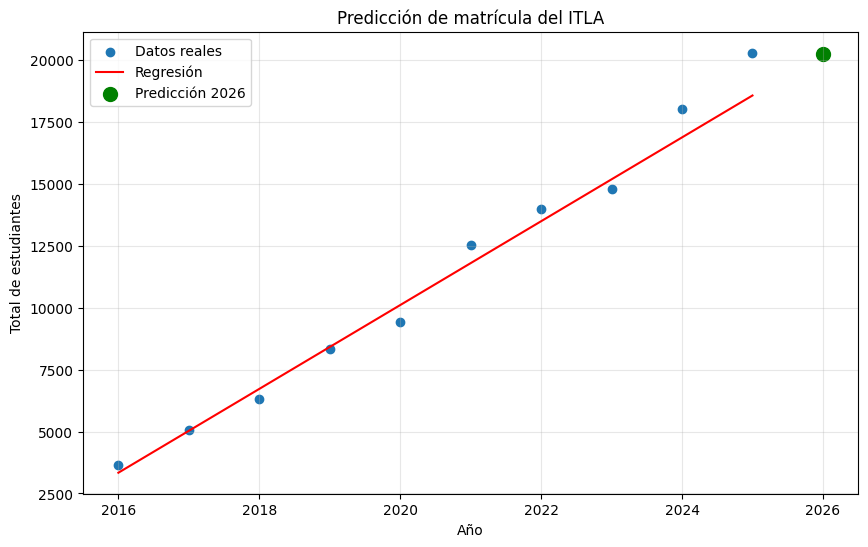

In [ ]:
plt.figure(figsize=(10,6))

plt.scatter(matricula_anual["Año"], matricula_anual["Total"], label="Datos reales")

plt.plot(matricula_anual["Año"],
         modelo.predict(X),
         color="red",
         label="Regresión")

plt.scatter(2026, pred_2026,
            color="green",
            s=100,
            label="Predicción 2026")

plt.title("Predicción de matrícula del ITLA")
plt.xlabel("Año")
plt.ylabel("Total de estudiantes")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [ ]:
print("Crecimiento anual estimado:", round(modelo.coef_[0]))

Crecimiento anual estimado: 1692


 Con todos los datos

Reentrenado con 2016-2025

In [ ]:
modelo.fit(X, y)
pred_2026 = modelo.predict(pd.DataFrame({"Año":[2026]}))[0]

In [ ]:
print(f"Predicción de matrícula para 2026: {int(pred_2026)} estudiantes")

Predicción de matrícula para 2026: 21331 estudiantes


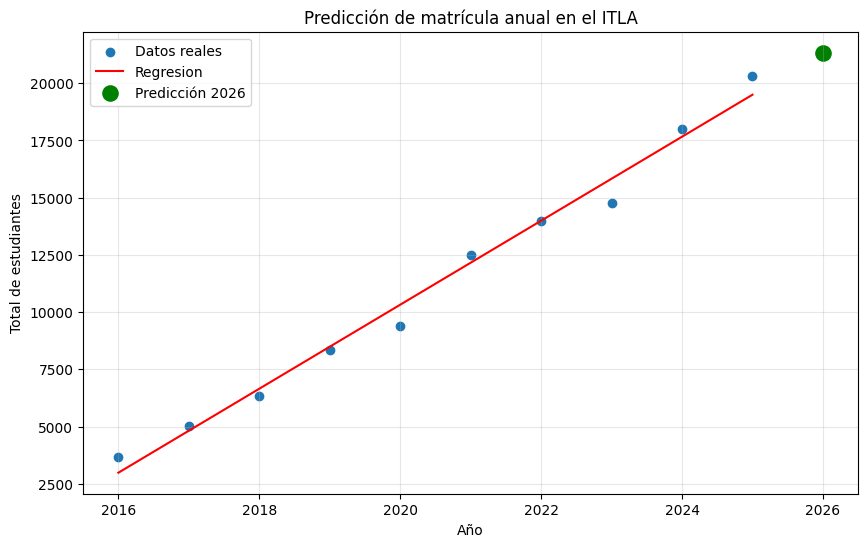

In [ ]:
plt.figure(figsize=(10,6))

plt.scatter(X["Año"], y, label="Datos reales")

plt.plot(X["Año"],
         modelo.predict(X),
         color="red",
         label="Regresion")

plt.scatter(2026, pred_2026,
            color="green",
            s=120,
            label="Predicción 2026")

plt.title("Predicción de matrícula anual en el ITLA")
plt.xlabel("Año")
plt.ylabel("Total de estudiantes")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

##carreras proyectadas para 2k16


In [ ]:
predicciones_carreras = []

for carrera in df["Carrera"].unique():
    df_c = df[df["Carrera"] == carrera].groupby("Año")["Total"].sum().reset_index()
    if len(df_c) < 5:
        continue
    modelo_c = LinearRegression()
    modelo_c.fit(df_c[["Año"]], df_c["Total"])
    pred = modelo_c.predict(pd.DataFrame({"Año": [2026]}))[0]
    r2 = r2_score(df_c["Total"], modelo_c.predict(df_c[["Año"]]))
    predicciones_carreras.append({"Carrera": carrera, "Predicción 2026": int(pred), "R²": round(r2, 4)})

ranking = pd.DataFrame(predicciones_carreras).sort_values("Predicción 2026", ascending=False).reset_index(drop=True)
print(ranking.head(10))

                                             Carrera  Predicción 2026      R²
0                Tecnólogo en Desarrollo de Software             8031  0.9716
1                 Tecnólogo en Seguridad Informática             3705  0.7585
2                            Tecnólogo en Multimedia             3262  0.9800
3                           Tecnólogo en Mecatrónica             1303  0.5067
4      Tecnólogo en Analítica y Ciencia de los Datos              991  0.9573
5                                Tecnólogo en Sonido              911  0.0505
6                   Tecnólogo en Informática Forense              729  0.8986
7               Tecnólogo en Inteligencia Artificial              701  0.9114
8                  Tecnólogo en Redes de Información              666  0.4367
9  Tecnólogo en Desarrollo de Simulaciones Intera...              657  0.9953
